

# Divide continuous data into equally-spaced epochs

This tutorial shows how to segment continuous data into a set of epochs spaced
equidistantly in time. The epochs will not be created based on experimental events;
instead, the continuous data will be "chunked" into consecutive epochs (which may be
temporally overlapping, adjacent, or separated). We will also briefly demonstrate how
to use these epochs in connectivity analysis.

First, we import the necessary modules and read in a sample raw data set.
This data set contains brain activity that is event-related, i.e.,
synchronized to the onset of auditory stimuli. However, rather than creating
epochs by segmenting the data around the onset of each stimulus, we will
create 30 second epochs that allow us to perform non-event-related analyses of
the signal.

<div class="alert alert-info"><h4>Note</h4><p>Starting in version 1.0, all functions in the ``mne.connectivity``
    sub-module are housed in a separate package called
    :mod:`mne-connectivity <mne_connectivity>`. Download it by  running:

```console
$ pip install mne-connectivity</p></div>
```


In [1]:
# Authors: The MNE-Python contributors.
# License: BSD-3-Clause
# Copyright the MNE-Python contributors.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mne_connectivity import envelope_correlation

import mne
from mne.preprocessing import compute_proj_ecg

sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file)

Opening raw data file /home/jshen/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.


For this tutorial we'll crop and resample the raw data to a manageable size
for our web server to handle, ignore EEG channels, and remove the heartbeat
artifact so we don't get spurious correlations just because of that.



In [3]:
raw.crop(tmax=150).resample(100).pick("meg")
ecg_proj, _ = compute_proj_ecg(raw, ch_name="MEG 0511")  # No ECG chan
raw.add_proj(ecg_proj)
raw.apply_proj()

221 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
221 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Including 3 SSP projectors from raw file
Running ECG SSP computation
Using channel MEG 0511 to identify heart beats.
Setting up band-pass filter from 5 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 5.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 4.75 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 35.25 Hz)
- Filter length: 1000 samples (10.000 s)

Number of ECG events detected : 165 (average pulse 66.0 / min.)
Computing projector
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.3s


Not setting metadata
165 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Using data from preloaded Raw for 165 events and 61 original time points ...


[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 305 out of 305 | elapsed:    0.6s finished


    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on MAG : ['MEG 1411', 'MEG 1421']
3 bad epochs dropped
Adding projection: planar--0.200-0.400-PCA-01 (exp var=75.9%)
Adding projection: planar--0.200-0.400-PCA-02 (exp var=15.5%)
Adding projection: axial--0.200-0.400-PCA-01 (exp var=93.7%)
Adding projection: axial--0.200-0.400-PCA-02 (exp var=2.8%)
No channels 'eeg' found. Skipping.
Done.
7 projection items deactivated
Created an SSP operator (subspace dimension = 7)
7 projection items activated
SSP projectors applied...


<Raw | sample_audvis_raw.fif, 306 x 15000 (150.0 s), ~38.2 MiB, data loaded>

To create fixed length epochs, we simply call the function and provide it
with the appropriate parameters indicating the desired duration of epochs in
seconds, whether or not to preload data, whether or not to reject epochs that
overlap with raw data segments annotated as bad, whether or not to include
projectors, and finally whether or not to be verbose. Here, we choose a long
epoch duration (30 seconds). To conserve memory, we set ``preload`` to
``False``.



In [4]:
epochs = mne.make_fixed_length_epochs(raw, duration=30, preload=False)

Not setting metadata
5 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 7)
7 projection items activated


## Characteristics of Fixed Length Epochs
Fixed length epochs are generally unsuitable for event-related analyses. This
can be seen in an image map of our fixed length
epochs. When the epochs are averaged, as seen at the bottom of the plot,
misalignment between onsets of event-related activity results in noise.



Using data from preloaded Raw for 5 events and 3000 original time points ...
0 bad epochs dropped
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


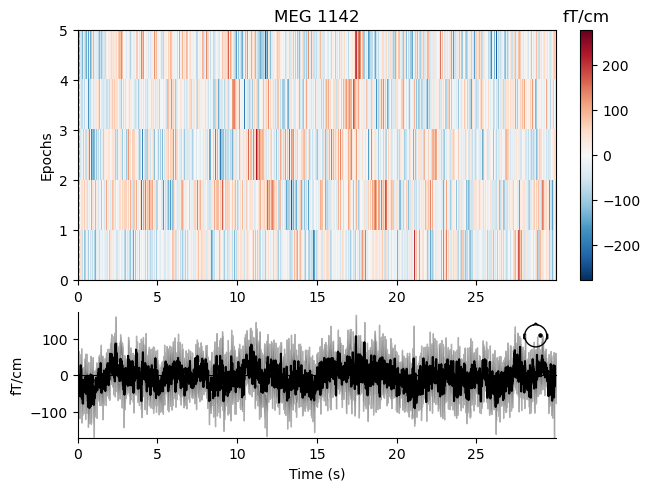

In [5]:
event_related_plot = epochs.plot_image(picks=["MEG 1142"])

For information about creating epochs for event-related analyses, please see
`tut-epochs-class`.

## Example Use Case for Fixed Length Epochs: Connectivity Analysis
Fixed lengths epochs are suitable for many types of analysis, including
frequency or time-frequency analyses, connectivity analyses, or
classification analyses. Here we briefly illustrate their utility in a sensor
space connectivity analysis.

The data from our epochs object has shape ``(n_epochs, n_sensors, n_times)``
and is therefore an appropriate basis for using MNE-Python's envelope
correlation function to compute power-based connectivity in sensor space. The
long duration of our fixed length epochs, 30 seconds, helps us reduce edge
artifacts and achieve better frequency resolution when filtering must
be applied after epoching.

Let's examine the alpha band. We allow default values for filter parameters
(for more information on filtering, please see `tut-filter-resample`).



In [6]:
epochs.load_data().filter(l_freq=8, h_freq=12)
alpha_data = epochs.get_data(copy=False)

Using data from preloaded Raw for 5 events and 3000 original time points ...
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 165 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    2.5s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    2.6s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    2.7s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    2.8s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    3.0s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    3.1s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    3.3s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    3.5s
[Parallel(n_jobs=1)]: Done 1530 out of 1530 | elapsed:    3.5s finished


If desired, separate correlation matrices for each epoch can be obtained.
For envelope correlations, this is the default return if you use
:meth:`mne-connectivity:mne_connectivity.EpochConnectivity.get_data`:



In [7]:
corr_matrix = envelope_correlation(alpha_data).get_data()
print(corr_matrix.shape)

(5, 306, 306, 1)


Now we can plot correlation matrices. We'll compare the first and last
30-second epochs of the recording:



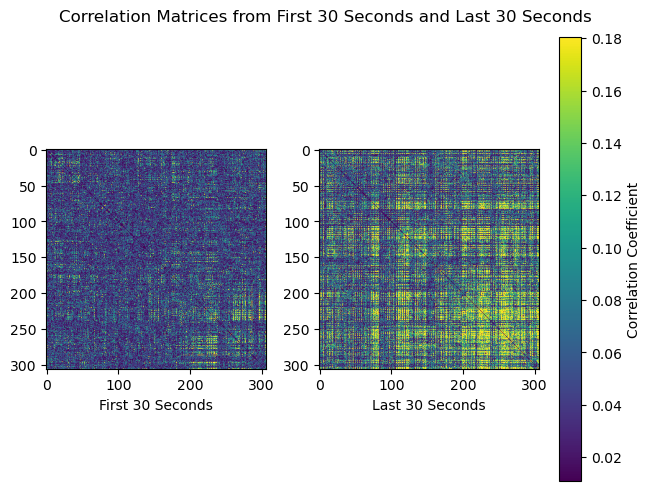

In [8]:
first_30 = corr_matrix[0]
last_30 = corr_matrix[-1]
corr_matrices = [first_30, last_30]
color_lims = np.percentile(np.array(corr_matrices), [5, 95])
titles = ["First 30 Seconds", "Last 30 Seconds"]

fig, axes = plt.subplots(nrows=1, ncols=2, layout="constrained")
fig.suptitle("Correlation Matrices from First 30 Seconds and Last 30 Seconds")
for ci, corr_matrix in enumerate(corr_matrices):
    ax = axes[ci]
    mpbl = ax.imshow(corr_matrix, clim=color_lims)
    ax.set_xlabel(titles[ci])
cbar = fig.colorbar(ax.images[0], label="Correlation Coefficient")